Practical 9

**AIM:-** To implement the K-Mean clusturing algorithm and analyze the clusturing result using appropriate evaluation Technique

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
path= "/content/drive/MyDrive/ML_Dataset/Mall_Customers.csv"
df=pd.read_csv(path)
df.head(5)

In [3]:
path= "/content/drive/MyDrive/mldataset/Mall_Customers.csv"
df=pd.read_csv(path)
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
X = df.iloc[:, [3, 4]].values


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


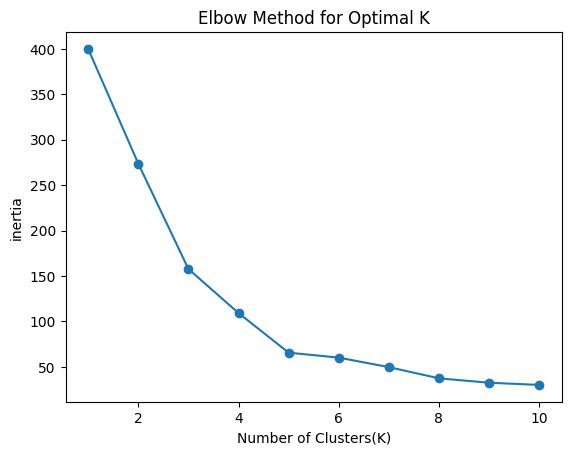

In [6]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print(inertia_values)

plt.figure()
plt.plot(range(1,11), inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('inertia')
plt.show()

In [7]:
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = clusters
(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,5
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,5


In [8]:
print("Inertia:",kmeans.inertia_)

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Inertia: 60.132874871934206
Silhouette Score: 0.5138257534676561


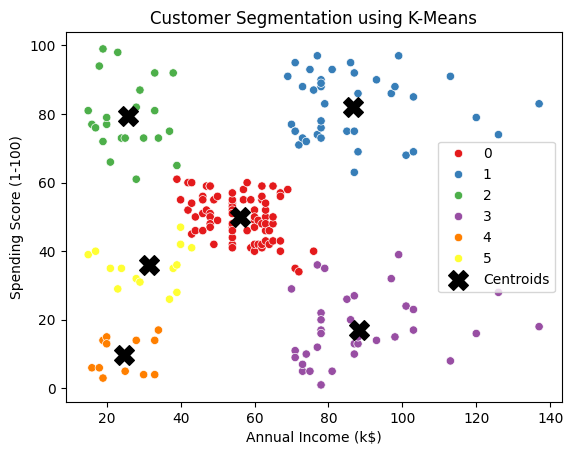

In [9]:
plt.figure()
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)' , hue='Cluster',
                data=df, palette='Set1'
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200, c='black', marker='X',
    label='Centroids'
 )

plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()